In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import flpoAgent 
import importlib 
import random 
from scipy.spatial.distance import cdist 
import createEnv 
from scipy.optimize import Bounds, LinearConstraint, minimize 
import supporting_functions 
from matplotlib.cm import get_cmap 

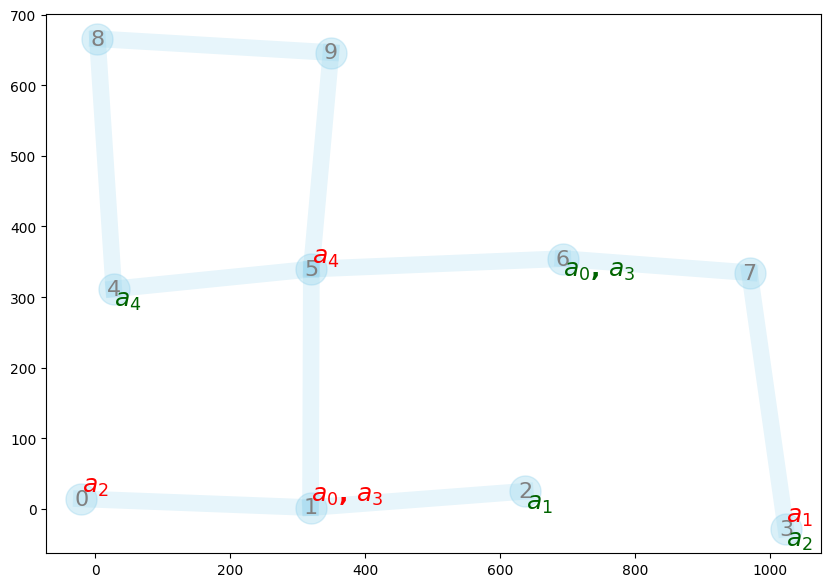

In [2]:
importlib.reload(flpoAgent)
importlib.reload(createEnv)
importlib.reload(supporting_functions)

# generate waypoints and the adjacency matrix
n_waypoints = 10
n_agents = 5
tolArray = np.random.uniform(10.0, 10.0, n_waypoints)

# Grid network parameters
grid_params = {
    'type':'grid',
    'n_points':n_waypoints,
    'grid_size':1000,
    'noise_factor':30
}

# Ring network parameters
ring_params = {
    'type':'ring',
    'num_rings':3,
    'points_per_ring':int(n_waypoints/3),
    'center_distance':1000,
    'deformation_level':50.0,
    'extra_connections':0.00,
    'missing_connections':0.05
}

# ellispoid cbf mode
ca_cbf_el = {
    'mode':'ellipse',
    'major_axis':1e-3*tolArray,
    'minor_axis':1e-4*tolArray,
    'degree':2
}

# linear cbf mode
ca_cbf_lin = {
    'mode':'linear',
    'eps':1e-4*tolArray,
    'eta':0
}

# cost mode options
cost_mode = 'sum' # 'slowest'
lm = 1 # for slowest

# create a mars environment
mars = createEnv.MARS(
    n_waypoints, 
    n_agents, 
    tolArray, 
    grid_params, 
    seed=12, 
    offset_energy=1,
    stagewiseCostCoeffs=np.array([1.0, 100.0, 1.0]),
    selfHop=0,
    ca_cbf=ca_cbf_lin,
    cost_mode=cost_mode,
    lm = lm,
    printFlag=False)

# mars visualization 
cmap = plt.get_cmap('tab20') 
agent_colors = {a: cmap(i / mars.n_agents) for i, a in enumerate(range(mars.n_agents))} 
createEnv.plotNetwork(mars=mars, figuresize=(10,7), routes=[], agent_colors=agent_colors, showEdgeLength=False) 

# agent visualization
# show_graph=0
# if show_graph:
#     for i,v in enumerate(mars.agents):
#         v.showGraph(mars.wp_locations, mars.dist_mat, mars.mask, mars.sched_mat[i,:], figuresize=(10,5), showEdgeTimeLim=True)



In [3]:
beta_min = 1e-3
beta_max = 1e3
beta_grow = 3
beta = beta_min
beta_arr = []
while beta <= beta_max:
    beta_arr.append(beta)
    beta = beta * beta_grow

T0 = mars.sched_mat
# T0 = np.ones((mars.n_agents, mars.n_waypoints))
# for i in range(mars.n_agents):
#     if i > 0:
#         T0[i] = T0[i-1] + mars.tolArray + np.random.uniform(0, 5, mars.tolArray.shape)
# T0 = np.random.uniform(0, 10, (mars.n_agents, mars.n_waypoints))
V0 = mars.speed_vec

optimizer = {
    'name':'slsqp',
    'dt_init':0.1,
    'dt_min':1e-5,
    'dt_max':0.1,
    'Tf':10,
    'gamma':1,
    'alpha_s':1,
    'alpha_c':10,
    'alpha_r':10,
    'alpha_q':10,
    'p':1,
    'stop_tol':0.5,
    'stop_tol_weight':np.array([1, 1, 5, 5]),
    'verbose':2
}

optimizer = {
    'name':'SLSQP',
    'stop_tol':0.5,
    'disp':False
}

mars.ca_cbf = ca_cbf_el
cbf_mode = mars.ca_cbf['mode']
print(f'mars cbf mode: {cbf_mode}')
# H0, GradH0 = mars.CBF_waypoints(T0, range(mars.n_waypoints), returnGrad=True) 
# np.min(H0), np.max(H0) 


mars cbf mode: ellipse


In [ ]:

active_waypoints = range(mars.n_waypoints) 
print(beta_arr) 
T, V, F, Pb_a = mars.anneal( 
    beta_arr, 
    T0, 
    V0, 
    active_waypoints=active_waypoints, 
    optimizer=optimizer, 
    annealPrint=True) 

mars.sched_mat = T 
mars.speed_vec = V 

